In [30]:
# Food101 Dataset'inin içinden bazı tatlı görselleri alınmıştır. 4 çeşit tatlımız vardır
# Donut, baklava, cupcakes, cannoli
# test-train otomatik olarak ayrılmıştır
import torch
from torch import nn
import numpy as np

In [31]:
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "desert101"

In [32]:
image_path

WindowsPath('data/desert101')

In [33]:
import os
def check_data(dir_path):
    for dirpath, dirnames, filenames in os.walk(dir_path): # directory'deki dosyaları gezer
        print(f"# of directories : {len(dirnames)} and {len(filenames)} images in {dirpath}")

In [34]:
check_data(image_path)

# of directories : 2 and 1 images in data\desert101
# of directories : 4 and 1 images in data\desert101\test
# of directories : 0 and 20 images in data\desert101\test\baklava
# of directories : 0 and 20 images in data\desert101\test\cannoli
# of directories : 0 and 20 images in data\desert101\test\cup_cakes
# of directories : 0 and 20 images in data\desert101\test\donuts
# of directories : 4 and 1 images in data\desert101\train
# of directories : 0 and 80 images in data\desert101\train\baklava
# of directories : 0 and 80 images in data\desert101\train\cannoli
# of directories : 0 and 80 images in data\desert101\train\cup_cakes
# of directories : 0 and 80 images in data\desert101\train\donuts


In [35]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [36]:
train_dir

WindowsPath('data/desert101/train')

In [37]:
test_dir

WindowsPath('data/desert101/test')

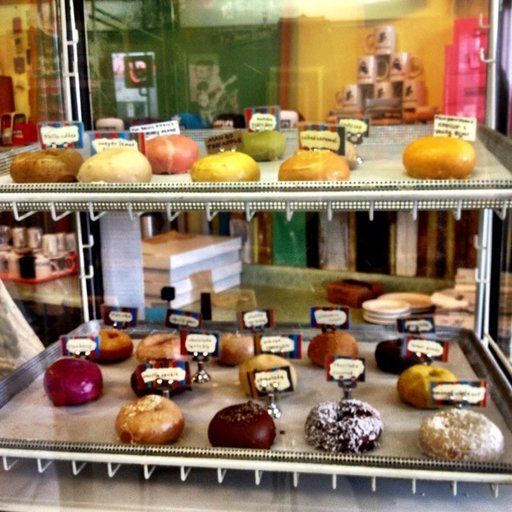

In [38]:
from PIL import Image
import random
random.seed(42)
image_path_list = list(image_path.glob("*/*/*.jpg")) #bulduğu bütün jpg dosyalarnı getirir
random_image = random.choice(image_path_list)
img = Image.open(random_image)
img

In [39]:
# DataLoader objelerini hazırlamak
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# data augmentation yapalım
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.4), # Horizontalflip yapıyoruz random olarak
    transforms.TrivialAugmentWide(), #Buradada rastgele augmentationlar uygalayacağız.
    transforms.ToTensor() # En sonda da tensora ceviriyoruz
])

In [40]:
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                  transform=data_transform,
                                  target_transform=None) # target_transfor default olarak None'dır.

In [41]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data\desert101\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [42]:
test_data

Dataset ImageFolder
    Number of datapoints: 77
    Root location: data\desert101\test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.4)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
           )

In [43]:
class_names = train_data.classes # hepsi ayrı klasörde olduğu için bu şekilde alabildik.

In [44]:
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [45]:
len(train_data), len(test_data)

(316, 77)

In [46]:
BATCH_SIZE = 32
#NUM_WORKERS = os.cpu_count()

In [47]:
#NUM_WORKERS # 12 çekirdekte çalıştıracağız bu değeri vermezsek default daha düşük çekirdekle çalışır.

In [48]:
train_dataloader = DataLoader(dataset = train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset = test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

In [49]:
train_dataloader

In [50]:
train_dataloader.dataset[0][0]

tensor([[[0.6000, 0.5922, 0.5333,  ..., 0.4784, 0.4510, 0.4549],
         [0.6431, 0.5608, 0.5216,  ..., 0.5294, 0.4588, 0.4706],
         [0.6863, 0.5569, 0.5647,  ..., 0.5765, 0.4824, 0.5490],
         ...,
         [0.9490, 0.9686, 0.9804,  ..., 0.8314, 0.8196, 0.8000],
         [0.9451, 0.9725, 0.9804,  ..., 0.7961, 0.8078, 0.8196],
         [0.9373, 0.9608, 0.9529,  ..., 0.8314, 0.8510, 0.8196]],

        [[0.4824, 0.4784, 0.4196,  ..., 0.3451, 0.3137, 0.3216],
         [0.5294, 0.4510, 0.4118,  ..., 0.4078, 0.3412, 0.3569],
         [0.5725, 0.4471, 0.4431,  ..., 0.4471, 0.3529, 0.4078],
         ...,
         [0.7098, 0.7686, 0.8157,  ..., 0.5922, 0.5725, 0.5451],
         [0.7216, 0.7961, 0.8157,  ..., 0.5647, 0.5725, 0.5765],
         [0.7098, 0.7647, 0.7647,  ..., 0.6314, 0.6431, 0.6000]],

        [[0.2118, 0.2157, 0.1686,  ..., 0.0980, 0.0824, 0.0902],
         [0.2314, 0.1804, 0.1529,  ..., 0.1451, 0.1020, 0.1137],
         [0.2510, 0.1804, 0.1569,  ..., 0.1686, 0.1098, 0.

In [51]:
# VGG mimarisini kopyalayacağız yine
class DesertClassifier(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units * 16 * 16,
                      out_features=output_shape)
        )
    
    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [52]:
model_0 = DesertClassifier(input_shape=3, hidden_units=32, output_shape=len(class_names))

In [53]:
from torchinfo import summary

In [54]:
summary(model_0, input_size =[1,3,64,64])
# Aslında modelin özetini çıkarır 02_CNN_deep_dive dosyasında yaptığımız işleme benzer.

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

In [55]:
# train ve test fonksiyonları
def train_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, optimizer: torch.optim.Optimizer):
    model.train()

    train_loss = 0
    train_acc = 0

    for batch, (X,y) in enumerate(dataloader):

        y_pred = model(X)
        loss = loss_fn(y_pred,y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss,train_acc

In [56]:
def test_step(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module):
    model.eval()

    test_loss = 0
    test_acc = 0

    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits,y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels ==y).sum().item() / len(test_pred_labels)

    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [57]:
def train(
        model: torch.nn.Module,
        train_dataloader: torch.utils.data.DataLoader,
        test_dataloader: torch.utils.data.DataLoader,
        optimizer: torch.optim.Optimizer,
        epochs: int = 10,
        loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
        ):
    
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }
    
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        
        test_loss, test_acc = test_step(model=model,
                                           dataloader=test_dataloader,
                                           loss_fn=loss_fn)

        print(f"Epoch: {epoch + 1}, Train Loss: {train_loss}, Train Acc: {train_acc}, Test Loss: {test_loss}, Test Acc: {test_acc}")

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

In [58]:
# Eğitim ve sonuçlar
EPOCHS = 10
model_0 = DesertClassifier(input_shape=3,
                           hidden_units=32,
                           output_shape=len(class_names))
optimizer = torch.optim.Adam(params=model_0.parameters(), lr =0.001)
model_0_results = train(model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=test_dataloader,
                        optimizer=optimizer,
                        epochs=EPOCHS)

Epoch: 1, Train Loss: 1.3921168208122254, Train Acc: 0.21026785714285717, Test Loss: 1.389007528622945, Test Acc: 0.19791666666666666
Epoch: 2, Train Loss: 1.3864134550094604, Train Acc: 0.2517857142857143, Test Loss: 1.3851991097132366, Test Acc: 0.23958333333333334
Epoch: 3, Train Loss: 1.3743781447410583, Train Acc: 0.2883928571428572, Test Loss: 1.3515779972076416, Test Acc: 0.31009615384615385
Epoch: 4, Train Loss: 1.3252642393112182, Train Acc: 0.38303571428571426, Test Loss: 1.3590654134750366, Test Acc: 0.2860576923076923
Epoch: 5, Train Loss: 1.3166308641433715, Train Acc: 0.37008928571428573, Test Loss: 1.457181731859843, Test Acc: 0.2708333333333333
Epoch: 6, Train Loss: 1.3159753918647765, Train Acc: 0.37142857142857144, Test Loss: 1.3360008398691814, Test Acc: 0.3533653846153846
Epoch: 7, Train Loss: 1.2778634786605836, Train Acc: 0.39419642857142856, Test Loss: 1.2731103897094727, Test Acc: 0.3838141025641026
Epoch: 8, Train Loss: 1.2874451875686646, Train Acc: 0.42008928

In [59]:
model_0_results

{'train_loss': [1.3921168208122254,
  1.3864134550094604,
  1.3743781447410583,
  1.3252642393112182,
  1.3166308641433715,
  1.3159753918647765,
  1.2778634786605836,
  1.2874451875686646,
  1.2175811767578124,
  1.2703849077224731],
 'train_acc': [0.21026785714285717,
  0.2517857142857143,
  0.2883928571428572,
  0.38303571428571426,
  0.37008928571428573,
  0.37142857142857144,
  0.39419642857142856,
  0.42008928571428567,
  0.4424107142857143,
  0.40446428571428567],
 'test_loss': [1.389007528622945,
  1.3851991097132366,
  1.3515779972076416,
  1.3590654134750366,
  1.457181731859843,
  1.3360008398691814,
  1.2731103897094727,
  1.2938392162322998,
  1.3190292914708455,
  1.3022433916727703],
 'test_acc': [0.19791666666666666,
  0.23958333333333334,
  0.31009615384615385,
  0.2860576923076923,
  0.2708333333333333,
  0.3533653846153846,
  0.3838141025641026,
  0.4519230769230769,
  0.3060897435897436,
  0.3741987179487179]}

In [63]:
import matplotlib.pyplot as plt
def plot_loss_curves(results):
    loss = results["train_loss"]
    test_loss = results ["test_loss"]
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(16,8))

    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs,test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

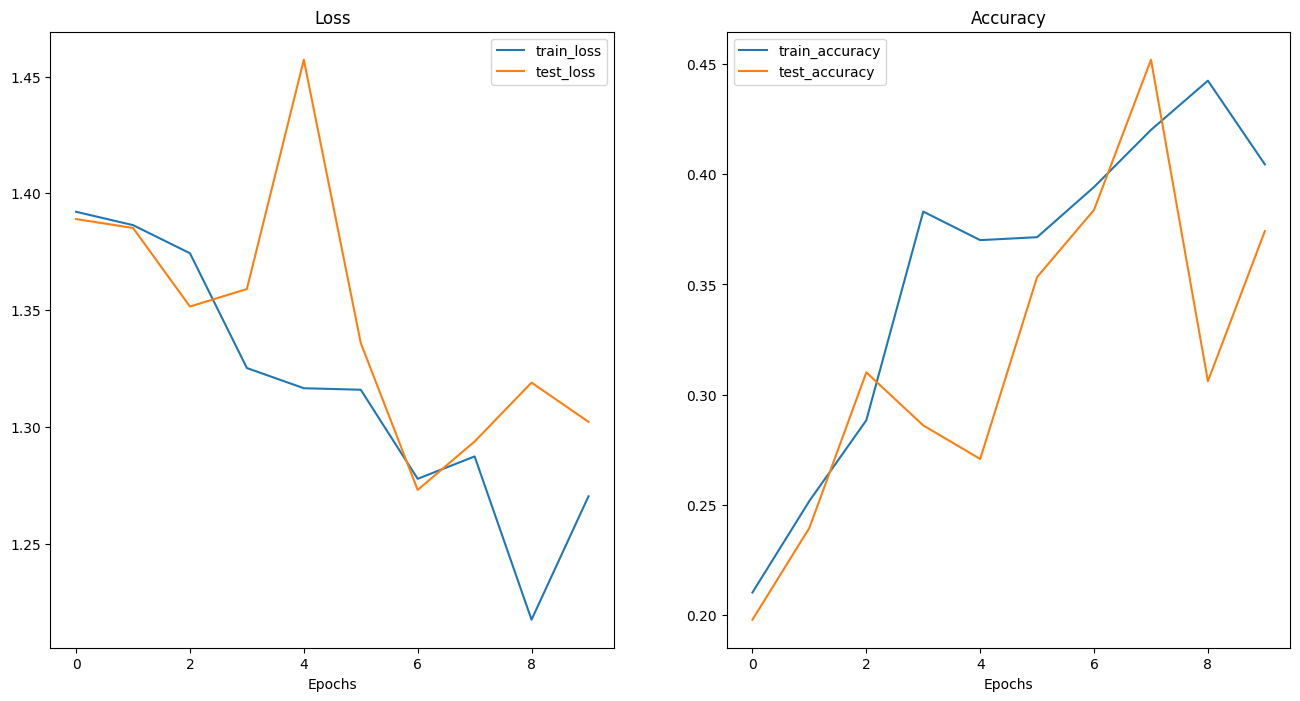

In [64]:
plot_loss_curves(model_0_results)